## Вывод

В ходе работы были выполнены загрузка и предварительная обработка данных, исследовательский анализ, корреляционный анализ, создание новых признаков и построение моделей машинного обучения для предсказания популярности музыкальных треков. Анализ показал, что между отдельными аудиопризнаками и целевой переменной `popularity` отсутствуют сильные линейные связи. В качестве базовой модели была использована линейная регрессия, которая показала лучшие результаты по сравнению с облегчённой моделью случайного леса. Таким образом, для рассматриваемого набора признаков линейная регрессия оказалась наиболее эффективным методом среди протестированных моделей.

Сравнение моделей показало, что линейная регрессия продемонстрировала лучшие результаты по всем используемым метрикам. Следовательно, в рамках данного исследования именно линейную регрессию можно считать наиболее удачной моделью среди протестированных подходов.

## Сравнение моделей

Сравним результаты базовой линейной регрессии и модели случайного леса по основным метрикам качества.

In [11]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,14.084883,19.124269,0.258862
1,Random Forest,17.156823,20.653262,0.135615


Результаты модели случайного леса показали более низкое качество по сравнению с линейной регрессией: средняя абсолютная ошибка составила 17.16, RMSE — 20.65, а коэффициент детерминации R² — 0.136. Таким образом, в текущей конфигурации облегчённая модель случайного леса уступила базовой линейной регрессии.

## Облегчённая модель случайного леса

Поскольку после кодирования категориальных признаков число признаков существенно увеличилось, для ускорения обучения была использована упрощённая версия модели случайного леса с ограниченной глубиной деревьев и уменьшенным числом деревьев.

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MAE: 17.156823044226254
RMSE: 20.65326236243775
R2: 0.1356154636508371


Результаты базовой модели линейной регрессии показали, что средняя абсолютная ошибка составила 14.08, а значение RMSE — 19.12. Коэффициент детерминации R² равен 0.259, что означает, что модель объясняет около 25.9% вариации целевой переменной `popularity`. Полученные результаты можно считать базовым ориентиром для дальнейшего сравнения с более сложными нелинейными моделями.

## Базовая модель линейной регрессии

В качестве базового подхода построим модель линейной регрессии и оценим её качество на тестовой выборке.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

MAE: 14.084882741863998
RMSE: 19.124268631488608
R2: 0.2588615656533789


## Подготовка данных к моделированию

Для построения базовой модели выделим целевую переменную, закодируем категориальные признаки и разделим данные на обучающую и тестовую выборки.

In [3]:
from sklearn.model_selection import train_test_split

df_model = df.copy()

df_model = pd.get_dummies(df_model, columns=['track_genre'], drop_first=True)

X = df_model.drop(columns=['popularity', 'artists'])
y = df_model['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((91200, 130), (22800, 130))

## Подготовка данных после перезапуска среды

После перезапуска вычислительной среды датафрейм был загружен заново из исходного файла `dataset.csv`. На этом этапе были удалены технические и избыточные признаки (`Unnamed: 0`, `track_id`, `album_name`, `track_name`), а также созданы новые признаки `duration_min`, `is_live` и `is_instrumental` для дальнейшего анализа и моделирования.

In [2]:
import pandas as pd

df = pd.read_csv('dataset.csv')

df = df.drop(columns=['Unnamed: 0', 'track_id', 'album_name', 'track_name'], errors='ignore')

df['duration_min'] = df['duration_ms'] / 60000
df['is_live'] = (df['liveness'] > 0.8).astype(int)
df['is_instrumental'] = (df['instrumentalness'] > 0.5).astype(int)

df.head()

,artists,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,is_live,is_instrumental
0,Gen Hoshino,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,0,0
1,Ben Woodward,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,0,0
2,Ingrid Michaelson;ZAYN,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,0,0
3,Kina Grannis,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,0,0
4,Chord Overstreet,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,0,0


Анализ новых признаков показал, что наиболее заметную связь с целевой переменной имеет `is_instrumental`, однако она остаётся слабой и отрицательной. Признаки `is_live` и `duration_min` практически не коррелируют с `popularity`. Это подтверждает вывод о том, что задача предсказания популярности, вероятно, требует применения более сложных нелинейных моделей.

## Корреляция новых признаков с целевой переменной

После создания новых признаков оценим их линейную связь с переменной `popularity`.

In [18]:
new_features_corr = df[['popularity', 'duration_min', 'is_live', 'is_instrumental']].corr()['popularity'].sort_values(ascending=False)
print(new_features_corr)

popularity         1.000000
is_live            0.006356
duration_min      -0.007101
is_instrumental   -0.090775
Name: popularity, dtype: float64


В ходе feature engineering были созданы новые признаки: `duration_min`, отражающий длительность трека в минутах, `is_live`, показывающий наличие признаков живого исполнения, и `is_instrumental`, характеризующий высокую инструментальность композиции. Эти признаки делают некоторые характеристики треков более интерпретируемыми и удобными для дальнейшего моделирования.

## Feature Engineering

На следующем этапе создадим новые признаки на основе исходных колонок. Это позволит представить некоторые характеристики трека в более удобной и интерпретируемой форме для модели.

In [17]:
df = df.drop(columns=['Unnamed: 0', 'track_id', 'album_name', 'track_name'], errors='ignore')

df['duration_min'] = df['duration_ms'] / 60000
df['is_live'] = (df['liveness'] > 0.8).astype(int)
df['is_instrumental'] = (df['instrumentalness'] > 0.5).astype(int)

df[['duration_ms', 'duration_min', 'liveness', 'is_live', 'instrumentalness', 'is_instrumental']].head()

,duration_ms,duration_min,liveness,is_live,instrumentalness,is_instrumental
0,230666,3.844433,0.3580,0,0.000001,0
1,149610,2.493500,0.1010,0,0.000006,0
2,210826,3.513767,0.1170,0,0.000000,0
3,201933,3.365550,0.1320,0,0.000071,0
4,198853,3.314217,0.0829,0,0.000000,0


Корреляционный анализ показал, что сильных линейных связей между отдельными признаками и целевой переменной `popularity` не наблюдается. Наиболее заметную отрицательную корреляцию имеет `instrumentalness`, а среди положительных признаков выделяются `loudness`, `explicit` и `danceability`. Это позволяет предположить, что для задачи могут лучше подойти нелинейные модели.

## Корреляция числовых признаков с таргетом

Для предварительной оценки полезности признаков выполним корреляционный анализ числовых и булевых признаков с целевой переменной `popularity`.

In [12]:
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'bool']).columns
corr_with_target = df[numeric_cols].corr()['popularity'].sort_values(ascending=False)
print(corr_with_target)

popularity          1.000000
loudness            0.050423
explicit            0.044082
danceability        0.035448
Unnamed: 0          0.032142
time_signature      0.031073
tempo               0.013205
energy              0.001056
key                -0.003853
liveness           -0.005387
duration_ms        -0.007101
mode               -0.013931
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64


## Популярность по жанрам

Для дополнительного анализа рассмотрим распределение популярности среди наиболее часто встречающихся жанров в датасете.

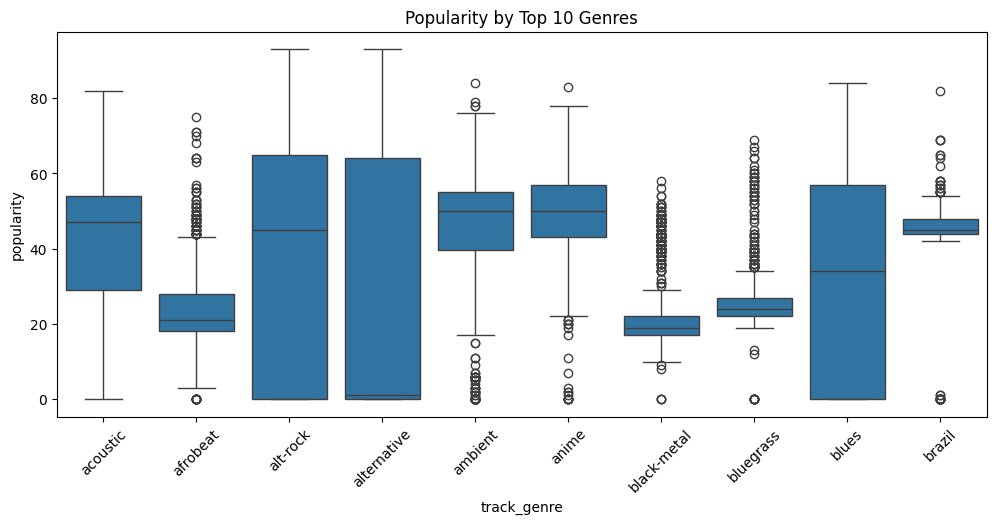

In [11]:
top_genres = df['track_genre'].value_counts().head(10).index
plt.figure(figsize=(12,5))
sns.boxplot(x='track_genre', y='popularity', data=df[df['track_genre'].isin(top_genres)])
plt.xticks(rotation=45)
plt.title('Popularity by Top 10 Genres')
plt.show()

## Связь танцевальности с популярностью

Рассмотрим зависимость между `danceability` и `popularity`, чтобы проверить, связана ли танцевальность трека с его популярностью.

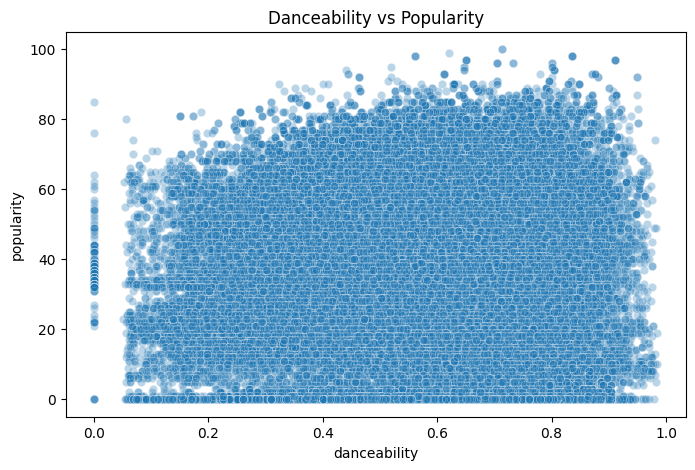

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='danceability', y='popularity', data=df, alpha=0.3)
plt.title('Danceability vs Popularity')
plt.show()

## Связь энергии трека с популярностью

Рассмотрим зависимость между `energy` и `popularity`, чтобы понять, связана ли энергетичность композиции с её популярностью.

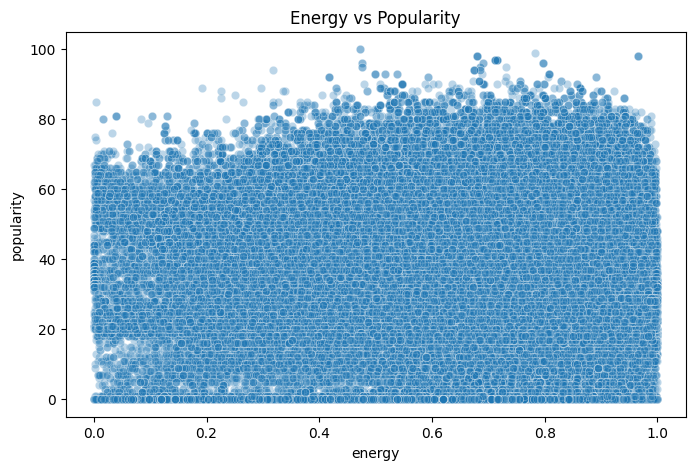

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='energy', y='popularity', data=df, alpha=0.3)
plt.title('Energy vs Popularity')
plt.show()

## Распределение длительности треков

Рассмотрим распределение признака `duration_ms`, чтобы понять, как обычно распределяется длительность треков в датасете и присутствуют ли выбросы.

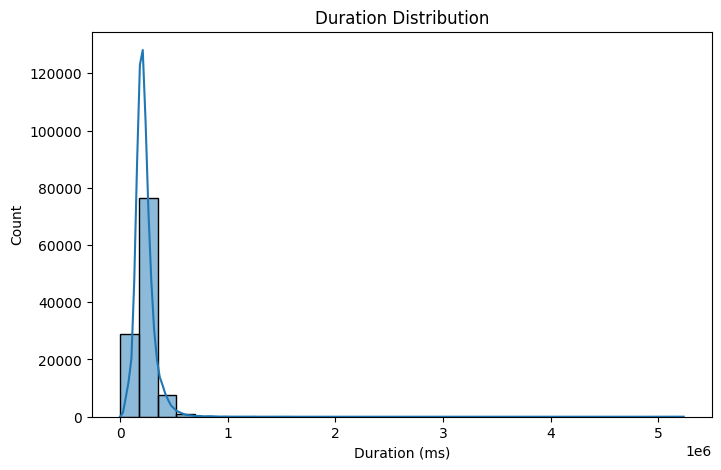

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['duration_ms'], bins=30, kde=True)
plt.title('Duration Distribution')
plt.xlabel('Duration (ms)')
plt.show()

## Распределение целевой переменной

Рассмотрим распределение целевой переменной `popularity`, чтобы понять, как значения популярности треков распределены в датасете.


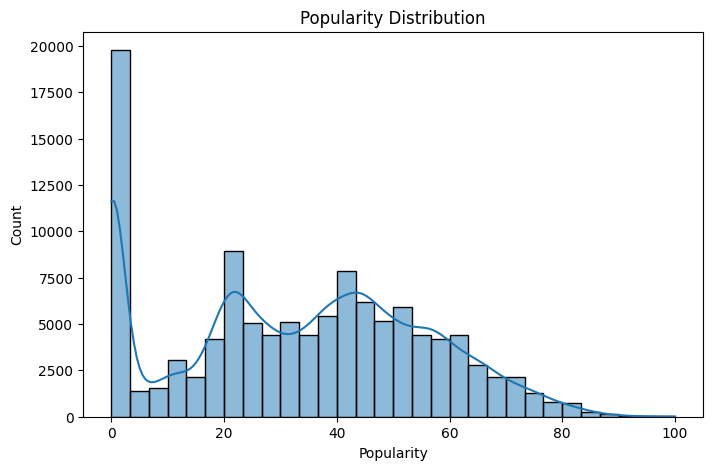

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.show()

## Общая информация о датасете

Датасет содержит 114000 строк и 21 столбец. В нём присутствуют числовые, категориальные и булевы признаки, описывающие музыкальные характеристики треков, а также информацию об исполнителе, альбоме и жанре. Пропусков в данных почти нет: отсутствующие значения встречаются только по одному разу в колонках `artists`, `album_name` и `track_name`. Целевая переменная `popularity` принимает значения от 0 до 100, что соответствует постановке задачи регрессии.

In [3]:
print("Размер таблицы:", df.shape)
print("\nТипы данных и пропуски:")
df.info()

print("\nКоличество пропусков:")
print(df.isnull().sum())

print("\nОписательная статистика:")
display(df.describe())

Размер таблицы: (114000, 21)

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalne

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Загрузка данных

Датасет Spotify был успешно загружен. По первым строкам видно, что каждая строка соответствует одному музыкальному треку, а столбцы содержат информацию об исполнителе, альбоме, жанре и аудиохарактеристиках композиции. Целевая переменная задачи — `popularity`, которую необходимо предсказать.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic
